In [1]:
import os
# from sklearn.svm import OneClassSVM
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None
from collections import Counter
import scipy.stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from statistics import mean
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.decomposition import SparsePCA
from sklearn.decomposition import TruncatedSVD
import umap

from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN, HDBSCAN
import math
from sklearn.metrics import silhouette_score
#import hypertools as hyp
# from RNA import General,Structure, Visual
import matplotlib
%matplotlib inline
from scipy.ndimage import gaussian_filter1d

2025-07-15 20:05:23.292748: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def CalculateSHAPEFromBitvector_mod(Modvect):
    Percentlist=[]
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    rates=NAI_one/(NAI_one+NAI_zero)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def CalculateSHAPEFromBitvector_control(Modvect,Unmodvect,alpha):
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    DMSO_two=np.sum(Unmodvect==2,axis=0)
    DMSO_zero=np.sum(Unmodvect==0,axis=0)
    delta=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    #delta=list(map(lambda x: x[0]-x[1], zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    rates=NAI_one/(NAI_one+NAI_zero)+np.multiply(delta,alpha)
    shapescore=Normal_SHAPE(rates)
    return shapescore
def CalculateSHAPEFromBitvector_control_fushu(Modvect,Unmodvect,alpha):
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    DMSO_two=np.sum(Unmodvect==2,axis=0)
    DMSO_zero=np.sum(Unmodvect==0,axis=0)
    #delta=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    delta=list(map(lambda x: x[0]-x[1], zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    rates=NAI_one/(NAI_one+NAI_zero)+np.multiply(delta,alpha)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def CalculateSHAPEFromBitvectors(Modvect,Unmodvect,alpha):
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    DMSO_two=np.sum(Unmodvect==2,axis=0)
    DMSO_zero=np.sum(Unmodvect==0,axis=0)
    delta=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),alpha*DMSO_two/(DMSO_two+DMSO_zero))))
    rates=NAI_one/(NAI_one+NAI_zero+NAI_two)+delta
    shapescore=Normal_SHAPE(rates)
    return shapescore


def Normal_SHAPE(inlist,windowsize=100,step=5): #采用icSHAPE-pipe的策略，在Windows内，top5%为1，最低5%为0
    shape=[[] for i in range(len(inlist))]
    finalshape=[0 for i in range(len(inlist))]
    start=0
    while start+windowsize< len(inlist):
        sublist=np.array(inlist[start:start+windowsize])
        s95=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 95)
        s5=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 5)
        subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in sublist]
        for i in range(windowsize):
            shape[start+i].append(subshape[i])
        start+=step
    #处理最后一个window
    endsublist=np.array(inlist[start:])
    s95=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 95)
    s5=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 5)
    subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in endsublist]
    for i in range(len(endsublist)):
        shape[start+i].append(subshape[i])
    #对每个位置的值求平均
    for i in range(len(inlist)):
        finalshape[i]=mean(shape[i])
    return finalshape
    
def get_index(lst=None, item=''):
    return [index for (index,value) in enumerate(lst) if value == item]

def color_SHAPE(shape_list, cutoff=[0.3, 0.5, 0.7]):
    """
    shape_list              -- A list of SHAPE scores
    cutoff                  -- Cutoff of SHAPE color boundaries.
    
    Transform SHAPE values to color blocks
    """
    color_blocks=[]
    for value in shape_list:
        if value == 'NULL':
            color_blocks.append('lightgray')
        else:
            shape = float(value)
            if shape < cutoff[0]:
                color_blocks.append('black')
            elif shape < cutoff[1]:
                color_blocks.append('blue')
            elif shape < cutoff[2]:
                color_blocks.append('orange')
            else:
                color_blocks.append('red')
    
    return color_blocks

# Cupinedotfile=General.load_dot('/data1/huangyong/Project/Nanopore/16S/16S_T.dot')
# Cupineseq=Cupinedotfile['16S'][0]
# Cupinedot=Cupinedotfile['16S'][1]
# posListCupine=[i for i in range(1,len(Cupineseq)+1)]

def SHAPEWindowcorrelation(shape1,shape2,windowsize):
    my_list1 = [0 if math.isnan(x) else x for x in shape1]
    my_list2 = [0 if math.isnan(x) else x for x in shape2]
    corre=[]
    start=0
    size=windowsize
    while start+size < len(my_list1):
        end=start+size
        subshape1=my_list1[start:end]
        subshape2=my_list2[start:end]
        t, p = scipy.stats.pearsonr(subshape1, subshape2)
        corre.append(round(t, 3))
        start+=1
    head=[0 for i in range(int(windowsize/2))]
    return corre+head*2

def plotPCA(pcadata,clust_ids,samplelabel,cluser_ratio):
    """
    pcadata                       --The PCA dataframe in which include two columns(PC1 and PC2)
    clust_ids                     --A list of cluster labels of each reads. e.g [0,0,1,2,0,1,2]
    cluser_ratio                  -- The reads ratio of each cluster.
    outfile                       -- The output figure.
    Plot the PCA clustering result 
    """    
    cluster_color = { 0: 'red', 1: '#FF7F00', 2: '#FF00FF',3:'#0000FF',4:'yellow',5:'black'}
    fig = plt.figure(figsize = (6,6))
    ax = fig.add_subplot(111)
    plt.scatter(pcadata['PC1'], pcadata['PC2'], c = [cluster_color[x]  if x in samplelabel else 'gray' for x in clust_ids], s = 20, alpha = 0.50 )
    ax.set_xlabel('PC 1', fontsize = 15)
    ax.set_ylabel('PC 2', fontsize = 15)
    N=len(cluser_ratio)
    for i in range(N):
        ax.text(0.05,0.95-0.05*i,'Cluter{}: {:.2%}'.format(i,cluser_ratio[i]),c=cluster_color[i], fontsize = 12, transform=ax.transAxes)
    ax.set_aspect('equal', 'box')
    plt.axis('equal')
    plt.show()
    #plt.savefig(outfile)
    #plt.close()
def filtVector(vector,posilist,minmod):
    start=posilist[0]
    end=posilist[1]
    temp_vet=vector.iloc[:,start:end].fillna(0)
    temp_totalnum=temp_vet.apply(lambda x: x.sum(),axis=1)
    filtvector=vector[temp_totalnum>minmod]
    return filtvector

def rainbowPlot(probList, ax, length=None, lw=0.8):
    max_height = 0
    for left,right in probList:
        x = (left+right)/2
        width = (right-left)
        height = width*0.01
        max_height = max(max_height, height/2)
        circle = matplotlib.patches.Arc((x, 0), width=width, angle=0, height=height, theta1=0, theta2=180, lw=lw)
        tmp = ax.add_artist(circle)
    ax.set_ylim(0, max_height)
def fill_ends(row):
    first_valid_index = int(row.first_valid_index())
    last_valid_index = int(row.last_valid_index())
    row.iloc[:first_valid_index] = 0
    row.iloc[last_valid_index + 1:] = 0
    return row


In [3]:
import shutil, tempfile
from RNA.Structure import *
from RNA.General import *
def __build_SHAPE_constraint(shape_list, outFn):
    """
    shape_list              -- A list of SHAPE scores
    outFn                   -- File name to save
    
    Build a SHAPE constraint file for RNAstructure
    """
    SHAPE = open(outFn, 'w')
    
    for idx in range(len(shape_list)):
        if shape_list[idx] != "NULL":
            SHAPE.writelines("%d\t%s\n" % (idx+1, shape_list[idx]))
        else:
            SHAPE.writelines("%d\t%s\n" % (idx+1, -999))
    
    SHAPE.close()


def __build_single_seq_fasta(sequence, outFn, label="test"):
    """
    sequence                -- Raw sequence
    outFn                   -- File name to save
    
    Build single-seq .fasta file for RNAstructure
    """
    SEQ = open(outFn, 'w')
    SEQ.writelines(f">{label}\n{sequence}\n")
    SEQ.close()

def __build_single_seq_file(sequence, outFn):
    """
    sequence                -- Raw sequence
    outFn                   -- File name to save
    
    Build single-seq .seq file for RNAstructure
    """
    SEQ = open(outFn, 'w')
    SEQ.writelines(";\nMySeq\n%s\n1\n" % (sequence, ))
    SEQ.close()

def __build_bp_constraint(bp_constraint, outFn):
    """ 
    bp_constraint           -- [[1,10], [2,9], [3,8]...] 1-based
    outFn                   -- File name to save
    
    Build a constraint file for RNAstructure
    """
    OUT = open(outFn, 'w')
    OUT.writelines("DS:\n-1\nSS:\n-1\nMod:\n-1\n")
    OUT.writelines("Pairs:\n")
    for left, right in bp_constraint:
        OUT.writelines("%s %s\n" % (left, right))
    
    OUT.writelines("-1 -1\n")
    OUT.writelines("FMN:\n-1\nForbids:\n-1 -1\n\n")
    OUT.close()

def __build_single_dot_file(sequence, dot, outFn, title='test_seq'):
    """
    sequence                -- Raw sequence
    dot                     -- Dot structure
    outFn                   -- File name to save
    title                   -- Sequence title
    
    Build a single sequence ct file for RNAstructure
    """
    assert len(sequence) == len(dot)
    open(outFn, 'w').writelines(">%s\n%s\n%s\n\n" % (title, sequence, dot))

def __read_Fold_outputCt(Ct_fn):
    """
    Read ct file generated by Fold program
    
    Return [(energy, dot), ...]
    If not energy not in ct file, energy will be NULL
    """
    
    ct_dict = General.load_ct(Ct_fn, True)
    
    str_list = []
    for i in ct_dict:
        seq, ct, length, info = ct_dict[i]
        assert len(seq) == length
        dot = ct2dot(ct, length)
        if '=' in info:
            energy = float(info.split('=')[1].lstrip().split()[0])
        else:
            energy = 'NULL'
        str_list.append((energy, dot))
    
    return str_list

def __read_RNAfold_output(RNAfold_output):
    """
    Read RNAfold output file

    Return [(energy, dot)]
    """
    content = open(RNAfold_output).readlines()
    seq = content[1].strip()
    dot, energy = content[2].strip().split()
    energy = float(energy[1:-1])
    return [(energy, dot)]
    
def predict_structure(sequence, shape_list=[], bp_constraint=[], mfe=True, clean=True, si=-0.6, sm=1.8, md=None, 
                      energy=True,noLP=False, verbose=False, outdir=None, method='Fold'):
    """
    sequence                -- Raw sequence
    shape_list              -- A list of SHAPE scores
    bp_constraint           -- [[1,10], [2,9], [3,8]...] 1-based
    mfe                     -- Use MFE algorithm, which is faster
    clean                   -- Delete all tmp files
    si                      -- Intercept
    sm                      -- Slope
    md                      -- Maximum pairing distance between nucleotides.
    noLP                    -- Produce structures without lonely pairs (helices of length 1)
                               Only useful for method=='RNAfold'
    verbose                 -- Print command
    method                  -- Fold or RNAfold
    
    Predict RNA secondary structure using Fold or Fold-smp
    
    Require: Fold or Fold-smp, ct2dot
    """
    
    assert method in ('Fold', 'RNAfold'), "method should be one of Fold/RNAfold"
    if outdir is None:
        ROOT = tempfile.mkdtemp(prefix="predict_structure_")
    else:
        ROOT = outdir
        os.makedirs(ROOT, exist_ok=True)
    fa_file = os.path.join(ROOT, "input.fa")
    shape_file = os.path.join(ROOT, "input.shape")
    constrain_file = os.path.join(ROOT, "input.const")
    out_file = os.path.join(ROOT, "output.ct")
    print(ROOT)
    
    __build_single_seq_fasta(sequence, fa_file, 'test')
    if shape_list:
        assert len(sequence) == len(shape_list)
        __build_SHAPE_constraint(shape_list, shape_file)
    if bp_constraint:
        __build_bp_constraint(bp_constraint, constrain_file)
    
    if method == 'Fold':
        Fold = General.require_exec("Fold-smp", exception=False)
        if not Fold:
            Fold = General.require_exec("Fold")
        Fold_CMD = f"{Fold} {fa_file} {out_file} -si {si} -sm {sm}"
        if shape_list:
            Fold_CMD += f" --SHAPE {shape_file}"
        if bp_constraint:
            Fold_CMD += f" --constraint {constrain_file}"
        if mfe:
            Fold_CMD += " -mfe"
        if md:
            Fold_CMD += f" --maxdistance {md}"
        if not verbose:
            Fold_CMD += ' > /dev/null'
    
    elif method == 'RNAfold':
        Fold = General.require_exec("RNAfold")
        
        Fold_CMD = f"{Fold} --infile={fa_file} --noPS"
        if shape_list:
            Fold_CMD += f' --shapeMethod="Dm{sm}b{si}" --shape={shape_file}'
        if bp_constraint:
            Fold_CMD += f" --constraint {constrain_file}"
        if md:
            Fold_CMD += f" --maxBPspan {md}"
        if noLP:
            Fold_CMD += f" --noLP"
        if verbose:
            Fold_CMD += " --verbose"
        Fold_CMD += f' > {out_file}'
    
    if verbose: 
        print( Colors.f(Fold_CMD, fc='yellow') )
    
    if clean:
        Run_catchKI(Fold_CMD, [ROOT])
    else:
        os.system(Fold_CMD)
    
    if method == 'Fold':
        structure_list = __read_Fold_outputCt(out_file)
    elif method == 'RNAfold':
        structure_list = __read_RNAfold_output(out_file)
    
    if mfe == True:
        structure = structure_list[0][1]
        e = structure_list[0][0]
    
    # clean
    if clean:
        shutil.rmtree(ROOT)
    if energy:
        return structure, e
    else:
        return structure

In [4]:
#分析自产的16S数据
BitvectorL270=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_270.event.profile.vect',sep='\t',index_col=0)
BitvectorL300=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_300.event.profile.vect',sep='\t',index_col=0)
BitvectorL310=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_310.event.profile.vect',sep='\t',index_col=0)
BitvectorL320=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_320.event.profile.vect',sep='\t',index_col=0)
BitvectorL670=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_670.event.profile.vect',sep='\t',index_col=0)
#BitvectorL1040=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_1040.event.profile.vect',sep='\t',index_col=0)
#BitvectorL1300=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_1300.event.profile.vect',sep='\t',index_col=0)
BitvectorL1530=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_1530.event.profile.vect',sep='\t',index_col=0)
BitvectorL1540=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitNAI/BS16S_1540.event.profile.vect',sep='\t',index_col=0)

# Cupinedotfile=General.load_dot('/data1/huangyong/Project/Nanopore/16S/16S_T.dot')
# Cupineseq=Cupinedotfile['16S'][0]
# Cupinedot=Cupinedotfile['16S'][1]
# posListCupine=[i for i in range(1,len(Cupineseq)+1)]

DMSOL270=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_270.event.profile.vect',sep='\t',index_col=0)
DMSOL300=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_300.event.profile.vect',sep='\t',index_col=0)
DMSOL310=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_310.event.profile.vect',sep='\t',index_col=0)
DMSOL320=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_320.event.profile.vect',sep='\t',index_col=0)
DMSOL670=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_670.event.profile.vect',sep='\t',index_col=0)
#DMSOL1040=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_1040.event.profile.vect',sep='\t',index_col=0)
#DMSOL1300=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_1300.event.profile.vect',sep='\t',index_col=0)
DMSOL1530=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_1530.event.profile.vect',sep='\t',index_col=0)
DMSOL1540=pd.read_csv('/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/splitDMSO/BS16S_1540.event.profile.vect',sep='\t',index_col=0)

[(0, 5325), (1, 4473)]


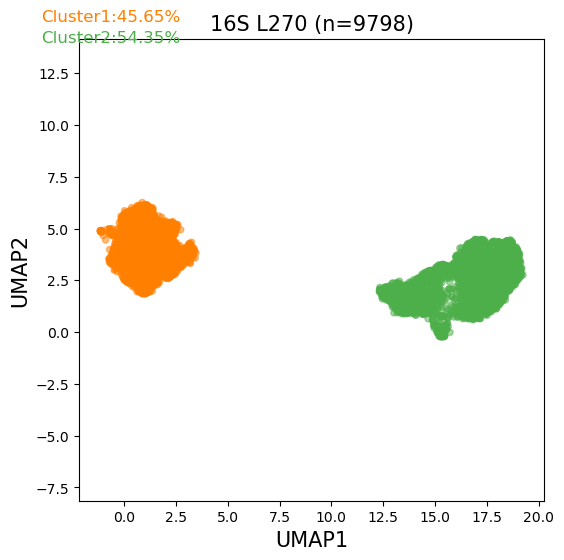

In [92]:
L270_classdf=BitvectorL270
np.random.seed(1)
UP = umap.UMAP(n_components=2)
L270_UMAP = pd.DataFrame(UP.fit_transform(L270_classdf),columns = ['UMAP1', 'UMAP2'])
#L270_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L270_UMAP)
#L270_clust_ids =L270_clustering.labels_.tolist()
L270_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(L270_UMAP)
L270_clust_ids = L270_clustering.predict(L270_UMAP).tolist()
print(Counter(L270_clust_ids).most_common(int(3)))
cluster_color = { 0:'#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L270_number_c1=L270_clust_ids.count(1)/len(L270_clust_ids)
L270_number_c2=L270_clust_ids.count(0)/len(L270_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L270_UMAP['UMAP1'], L270_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L270_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,15,'Cluster1:{:.2%}'.format(L270_number_c1),c=cluster_color[1],fontsize = 12)
ax.text(-4,14,'Cluster2:{:.2%}'.format(L270_number_c2),c=cluster_color[0], fontsize = 12)

ax.set_title(f'16S L270 (n={len(L270_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
# plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/270.PCA.pdf")
plt.close()
L270_C1=L270_classdf.iloc[get_index(L270_clust_ids,1),:]
L270_C2=L270_classdf.iloc[get_index(L270_clust_ids,0),:]
L270_score1=CalculateSHAPEFromBitvector_control(L270_C1,DMSOL270,1)
L270_score2=CalculateSHAPEFromBitvector_control(L270_C2,DMSOL270,1)

L270_resdf = L270_classdf.copy()
L270_resdf['group'] = 'L270'
L270_resdf['UMAP1'] = L270_UMAP['UMAP1'].values.copy()
L270_resdf['UMAP2'] = L270_UMAP['UMAP2'].values.copy()
L270_resdf['GM_cluster'] = L270_clust_ids

[(0, 5324), (1, 4474)]


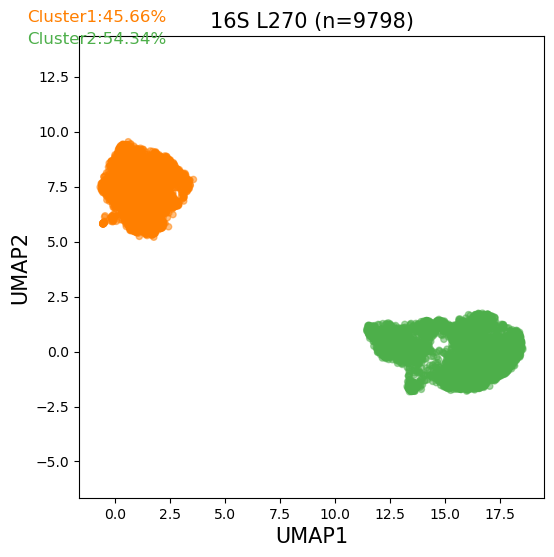

In [5]:
L270_classdf=BitvectorL270
np.random.seed(1)
UP = umap.UMAP(n_components=2)
L270_UMAP = pd.DataFrame(UP.fit_transform(L270_classdf),columns = ['UMAP1', 'UMAP2'])
#L270_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L270_UMAP)
#L270_clust_ids =L270_clustering.labels_.tolist()
L270_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(L270_UMAP)
L270_clust_ids = L270_clustering.predict(L270_UMAP).tolist()
print(Counter(L270_clust_ids).most_common(int(3)))
cluster_color = { 0:'#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L270_number_c1=L270_clust_ids.count(1)/len(L270_clust_ids)
L270_number_c2=L270_clust_ids.count(0)/len(L270_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L270_UMAP['UMAP1'], L270_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L270_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,15,'Cluster1:{:.2%}'.format(L270_number_c1),c=cluster_color[1],fontsize = 12)
ax.text(-4,14,'Cluster2:{:.2%}'.format(L270_number_c2),c=cluster_color[0], fontsize = 12)

ax.set_title(f'16S L270 (n={len(L270_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
# plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/270.PCA.pdf")
plt.close()
L270_C1=L270_classdf.iloc[get_index(L270_clust_ids,1),:]
L270_C2=L270_classdf.iloc[get_index(L270_clust_ids,0),:]
L270_score1=CalculateSHAPEFromBitvector_control(L270_C1,DMSOL270,1)
L270_score2=CalculateSHAPEFromBitvector_control(L270_C2,DMSOL270,1)

L270_resdf = L270_classdf.copy()
L270_resdf['group'] = 'L270'
L270_resdf['UMAP1'] = L270_UMAP['UMAP1'].values.copy()
L270_resdf['UMAP2'] = L270_UMAP['UMAP2'].values.copy()
L270_resdf['GM_cluster'] = L270_clust_ids

In [203]:
from RNA import Structure, General, Visual
Cupinedotfile=General.load_dot('/data1/huangyong/Project/Nanopore/16S/16S_T.dot')
Cupineseq=Cupinedotfile['16S'][0]
# subseq=Cupineseq[0:270] #调整位置
# ct= Structure.predict_structure(subseq,si=-0.6,sm=2.2,md=150,method='RNAfold')
# print(subseq)
# print(ct)

In [7]:
subseq=Cupineseq[0:280]
print('C1',predict_structure(subseq,shape_list=L270_score1,si=-0.6,sm=2.2,md=150,
                        outdir='/home/huangyong/temp/L270_C1',method='RNAfold',clean=False))
print('C2',predict_structure(subseq,shape_list=L270_score2,si=-0.6,sm=2.2,md=150,
                             outdir='/home/huangyong/temp/L270_C2',method='RNAfold',clean=False))

/home/huangyong/temp/L270_C1
C1 ('(((((..((.(((((.(((((...)))))))))).))(((.....)))............(((..((.((((...(((((....)))))...)))).))....))).)))))......(((((((..((...(((((((.((((..((.((((((....)))))).))...)))).....((((((((((....)))))))))).....((((((....)))))).)))))))..)))))))))((......))...((((((((.......))))))))', -148.91)
/home/huangyong/temp/L270_C2
C2 ('(((((.(((.(((((.(((((...)))))))))).))........(((.......(((.......)))((((...(((((....)))))...))))...)))...).)))))......(((((((..((.(((.((....((((.....((((((....))))))......)))))))))((((((((((....)))))))))).....((((((....))))))..........)))))))))..............(((((((.......))))))).', -121.63)


[(0, 2704), (1, 2388)]


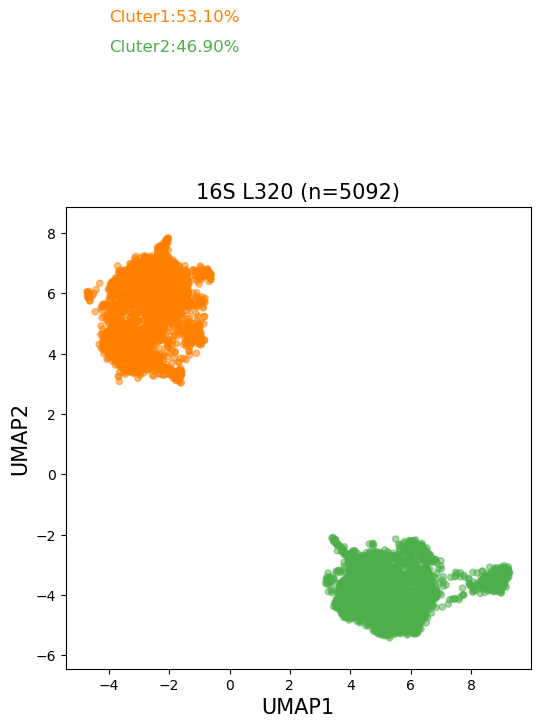

In [8]:
L320_classdf=BitvectorL320
np.random.seed(1)
UP = umap.UMAP(n_components=2)
L320_UMAP = pd.DataFrame(UP.fit_transform(L320_classdf),columns = ['UMAP1', 'UMAP2'])
#L320_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L320_UMAP)
#L320_clust_ids =L320_clustering.labels_.tolist()
L320_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(L320_UMAP)
L320_clust_ids = L320_clustering.predict(L320_UMAP).tolist()
print(Counter(L320_clust_ids).most_common(int(3)))
cluster_color = { 1: '#4daf4a', 0: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L320_number_c1=L320_clust_ids.count(0)/len(L320_clust_ids)
L320_number_c2=L320_clust_ids.count(1)/len(L320_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L320_UMAP['UMAP1'], L320_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L320_clust_ids],
            s = 20, alpha = 0.50, rasterized=True )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,15,'Cluter1:{:.2%}'.format(L320_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,14,'Cluter2:{:.2%}'.format(L320_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L320 (n={len(L320_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
# plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/320.PCA.pdf", dpi=300)
#plt.close()
L320_C1=L320_classdf.iloc[get_index(L320_clust_ids,0),:]
L320_C2=L320_classdf.iloc[get_index(L320_clust_ids,1),:]

L320_score1=CalculateSHAPEFromBitvector_control(L320_C1,DMSOL320,1)
L320_score2=CalculateSHAPEFromBitvector_control(L320_C2,DMSOL320,1)

L320_resdf = L320_classdf.copy()
L320_resdf['group'] = 'L320'
L320_resdf['UMAP1'] = L320_UMAP['UMAP1'].values.copy()
L320_resdf['UMAP2'] = L320_UMAP['UMAP2'].values.copy()
L320_resdf['GM_cluster'] = L320_clust_ids

In [9]:
subseq=Cupineseq[0:330]
print('C1',predict_structure(subseq,shape_list=L320_score1,si=-0.6,sm=2.2,md=150,
                        outdir='/home/huangyong/temp/L320_C1',method='RNAfold',clean=False))
print('C2', predict_structure(subseq,shape_list=L320_score2,si=-0.6,sm=2.2,md=150,
                              outdir='/home/huangyong/temp/L320_C2',method='RNAfold',clean=False))

/home/huangyong/temp/L320_C1
C1 ('.((((((.((((....((((..((..(..((........((((.((.(........))).))))..))..)))..))))....)))).)))))).....((((((((.((.....)).))).......)))))((((((.((((..((.((((((....)))))).))...)))).....((((((((((....)))))))))).....((((((....)))))).))))))..(((.((((..(((((((..(...((((((((.......))))))))...)..))))))).((((((((....))))...)))).....)))).)))', -174.57)
/home/huangyong/temp/L320_C2
C2 ('(((((.(((.(((((.(((((...)))))))))).))...................((.......)).((((...(((((....)))))...)))).........).)))))......(((((((..((...(((((((.((((.....((((((....))))))......)))).....((((((((((....)))))))))).....((((((....)))))).)))))))..)))))))))(((((((..(.....((((((.......)))))).....)..))))))).(((((.(.........).))))).............', -129.12)


[(0, 4165), (1, 655)]


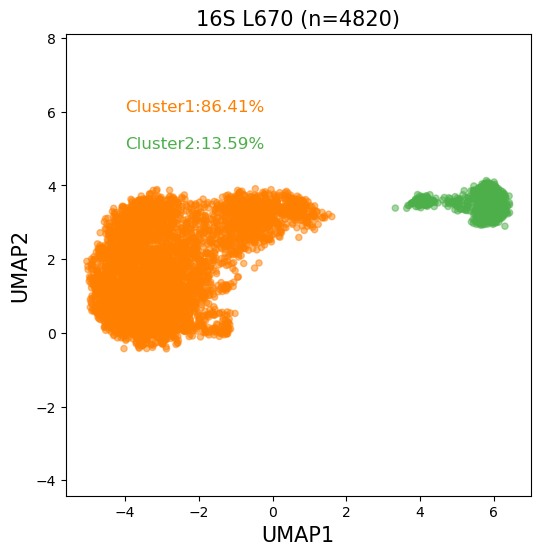

In [12]:
L670_classdf=BitvectorL670
np.random.seed(1)
UP = umap.UMAP(n_components=2)
L670_UMAP = pd.DataFrame(UP.fit_transform(L670_classdf),columns = ['UMAP1', 'UMAP2'])
#L670_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L670_UMAP)
#L670_clust_ids =L670_clustering.labels_.tolist()
L670_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(L670_UMAP)
L670_clust_ids = L670_clustering.predict(L670_UMAP).tolist()
print(Counter(L670_clust_ids).most_common(int(3)))
cluster_color = { 1: '#4daf4a', 0: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L670_number_c1=L670_clust_ids.count(0)/len(L670_clust_ids)
L670_number_c2=L670_clust_ids.count(1)/len(L670_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L670_UMAP['UMAP1'], L670_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L670_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,6,'Cluster1:{:.2%}'.format(L670_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,5,'Cluster2:{:.2%}'.format(L670_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L670 (n={len(L670_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/670.PCA.pdf")
#plt.close()
L670_C1=L670_classdf.iloc[get_index(L670_clust_ids,0),:]
L670_C2=L670_classdf.iloc[get_index(L670_clust_ids,1),:]

L670_score1=CalculateSHAPEFromBitvector_control(L670_C1,DMSOL670,1)
L670_score2=CalculateSHAPEFromBitvector_control(L670_C2,DMSOL670,1)


L670_resdf = L670_classdf.copy()
L670_resdf['group'] = 'L670'
L670_resdf['UMAP1'] = L670_UMAP['UMAP1'].values.copy()
L670_resdf['UMAP2'] = L670_UMAP['UMAP2'].values.copy()
L670_resdf['GM_cluster'] = L670_clust_ids

In [13]:
subseq=Cupineseq[0:680]
print('C1',predict_structure(subseq,shape_list=L670_score1,si=-0.6,sm=2.2,md=150,
                        outdir='/home/huangyong/temp/L670_C1',method='RNAfold',clean=False))
print('C2',predict_structure(subseq,shape_list=L670_score2,si=-0.6,sm=2.2,md=150,
                             outdir='/home/huangyong/temp/L670_C2',method='RNAfold',clean=False))

/home/huangyong/temp/L670_C1
C1 ('...(((.((.(((((.(((((...)))))))))).))..)))..............((..(((..((.((((...(((((....)))))...)))).))....)))..))........(((((((..((...(((((((.((((..((.((((((....)))))).))...)))).....((((((((((....)))))))))).....((((((....)))))).)))))))..)))))))))(((((((..(...((((((((.......))))))))...)..))))))).((((((((....)))...)))))....(((((.(((.....)))))))).((((....))))...............(.(((.....))).).......((((((((.(((((((((.....)))........)))..)))...))))))))((((((......((((((((((((.....)))))))).))))......))))))......(((((......(((((((..(.(......).)..))))))))))))...((((.(((.........((((.......))))(((..((((((((((..(((((((......(((((((.....)))))).)...)))))))...))))))))).)..)))......))).))))', -299.05)
/home/huangyong/temp/L670_C2
C2 ('(((((..((.(((((.(((((...)))))))))).))(((.....)))...........((((..((((.(((..(((((....)))))....((((.(.(((...............))).).))))))).))))..))))..)))))((((((....)))))).....(((....)))((((((((((....)))))))))).....((((((....)))))).(((((.........

In [14]:
__read_RNAfold_output('/home/huangyong/temp/L670_C1/output.ct')[0][0]

-299.05

In [15]:
__read_RNAfold_output('/home/huangyong/temp/L670_C2/output.ct')[0][0]

-269.71

[(0, 11454)]


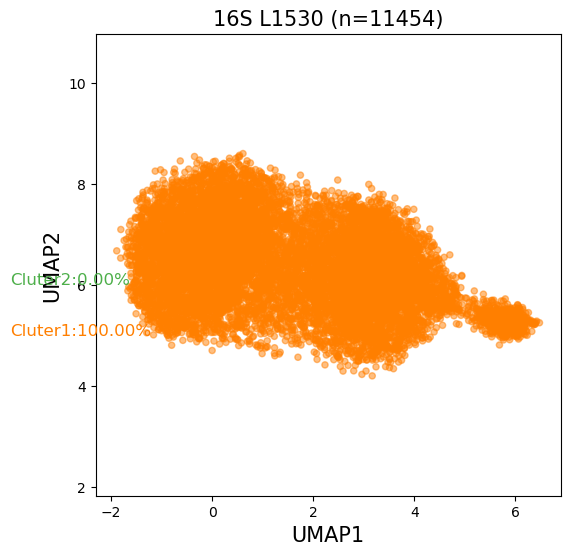

In [16]:
L1530_classdf=BitvectorL1530
UP = umap.UMAP(n_components=2)
L1530_UMAP = pd.DataFrame(UP.fit_transform(L1530_classdf),columns = ['UMAP1', 'UMAP2'])
#L1530_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L1530_UMAP)
#L1530_clust_ids =L1530_clustering.labels_.tolist()
L1530_clustering =GaussianMixture(n_components =1,covariance_type='full',random_state=1).fit(L1530_UMAP)
L1530_clust_ids = L1530_clustering.predict(L1530_UMAP).tolist()
print(Counter(L1530_clust_ids).most_common(int(3)))
cluster_color = { 1: '#4daf4a', 0: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L1530_number_c1=L1530_clust_ids.count(0)/len(L1530_clust_ids)
L1530_number_c2=L1530_clust_ids.count(1)/len(L1530_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L1530_UMAP['UMAP1'], L1530_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L1530_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,5,'Cluter1:{:.2%}'.format(L1530_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,6,'Cluter2:{:.2%}'.format(L1530_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L1530 (n={len(L1530_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/1530.PCA.pdf")
#plt.close()

L1530_C1=L1530_classdf.iloc[get_index(L1530_clust_ids,0),:]

L1530_score1=CalculateSHAPEFromBitvector_control(L1530_C1,DMSOL1530,1)

L1530_resdf = L1530_classdf.copy()
L1530_resdf['group'] = 'L1530'
L1530_resdf['UMAP1'] = L1530_UMAP['UMAP1'].values.copy()
L1530_resdf['UMAP2'] = L1530_UMAP['UMAP2'].values.copy()
L1530_resdf['GM_cluster'] = L1530_clust_ids

In [17]:
subseq=Cupineseq[0:1540]
print('C1',predict_structure(subseq,shape_list=L1530_score1,si=-0.6,sm=2.2,md=150,
                        outdir='/home/huangyong/temp/L1530_C1',method='RNAfold',clean=False))
# print('C2',predict_structure(subseq,shape_list=L670_score2,si=-0.6,sm=2.2,md=150,
#                              outdir='/home/huangyong/temp/L670_C2',method='RNAfold',clean=False))

/home/huangyong/temp/L1530_C1
C1 ('.((((((.((((....((((..((......(..(((((((.((.............))..))).))))..)))..))))....)))).))))))......((.(.(((((.........((((....)).))(((((((.((((..((.((((((....)))))).))...)))).....((((((((((....)))))))))).....((((((....)))))).)))))))....)))))).))...........((((((((.......)))))))).(((.((.(((((.((((((((....)))...))))).)).(((((.(((.....)))))))).((((....)))).................((((...(((((....))))).))))))).)).)))..................((((((((.....((((..((((((......((((..((((((.....))))))...))))......))))))))))..(((((......(((((((..(.(......).)..))))))))))))..)))..)))))........((((.......))))(((..((((((((((..(((((((......(((((((.....)))))).)...)))))))...))))))))).)..)))...((((....(((...((((((((.(.(((........)))..).))))))))...))).(((.((....)).))))))).(((.......)))(((....)))....(((((((.......((((.........))))....)))))))..........(((((((.(((((((((((((....))))))))..............))))).)))))))..(((...((((.(((((....)))))..))))..)))...((((((.((((.((((..(((..(......((.....

[(0, 10359)]


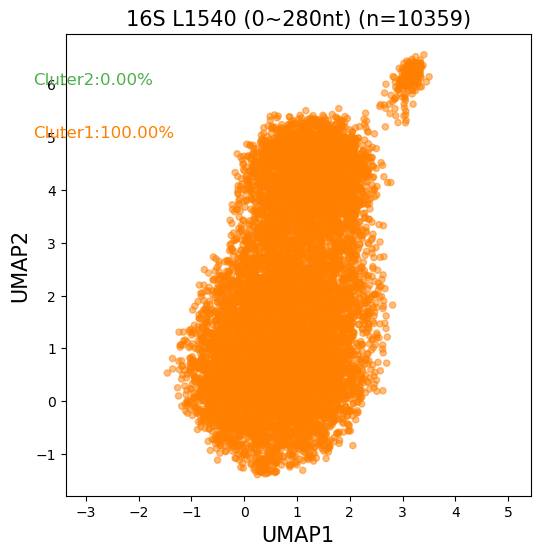

In [23]:
L1540_classdf=BitvectorL1540
np.random.seed(1)
UP = umap.UMAP(n_components=2)
L1540_UMAP = pd.DataFrame(UP.fit_transform(L1540_classdf),columns = ['UMAP1', 'UMAP2'])
#L1540_clustering =DBSCAN(eps=0.1, min_samples=2).fit(L1540_UMAP)
#L1540_clust_ids =L1540_clustering.labels_.tolist()
L1540_clustering =GaussianMixture(n_components =1,covariance_type='full',random_state=1).fit(L1540_UMAP)
L1540_clust_ids = L1540_clustering.predict(L1540_UMAP).tolist()
print(Counter(L1540_clust_ids).most_common(int(3)))
cluster_color = { 1: '#4daf4a', 0: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

L1540_number_c1=L1540_clust_ids.count(0)/len(L1540_clust_ids)
L1540_number_c2=L1540_clust_ids.count(1)/len(L1540_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(L1540_UMAP['UMAP1'], L1540_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1,2] else 'gray' for x in  L1540_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.text(-4,5,'Cluter1:{:.2%}'.format(L1540_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-4,6,'Cluter2:{:.2%}'.format(L1540_number_c2),c=cluster_color[1], fontsize = 12)

ax.set_title(f'16S L1540 (0~280nt) (n={len(L1540_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nano_seq/Nano_seq/BS16S/NanoDISHresult/result/1540.PCA.pdf")
#plt.close()

L1540_C1=L1540_classdf.iloc[get_index(L1540_clust_ids,0),:]

L1540_score1=CalculateSHAPEFromBitvector_control(L1540_C1,DMSOL1540,1)

L1540_resdf = L1540_classdf.copy()
L1540_resdf['group'] = 'L1540'
L1540_resdf['UMAP1'] = L1540_UMAP['UMAP1'].values.copy()
L1540_resdf['UMAP2'] = L1540_UMAP['UMAP2'].values.copy()
L1540_resdf['GM_cluster'] = L1540_clust_ids

In [24]:
len(L1540_score1)

1550

In [25]:
subseq=Cupineseq[0:1548]
print('C1',predict_structure(subseq,shape_list=L1540_score1[0:1548],si=-0.6,sm=2.2,md=150,
                        outdir='/home/huangyong/temp/L1540_C1',method='RNAfold',clean=False))

/home/huangyong/temp/L1540_C1
C1 ('.((((((.((((....((((...((.(..((..((((.(((..............))).)).))..))..).)).))))....)))).))))))........................(((((((..((...(((((((.((((..((.((((((....)))))).))...)))).....((((((((((....)))))))))).....((((((....)))))).)))))))..)))))))))(((((((..(...((((((((.......))))))))...)..))))))).((((((((....)))...)))))((((((.(........(.((((...(.((((..((((((...............))))))....((((....))))...)))))...)))).)).)))).))........((((((((.....((((..((((((......((((..((((((.....))))))...))))......))))))))))..(((((......(((((((..(.(......).)..))))))))))))..)))..))))).................(.(((((.....(((((((((..(((((((......(((((((.....)))))).)...)))))))...)))))))))))))).)...((((....(((...((((((((.(.(((........)))..).))))))))...))).(((.((....)).))))))).(((.......)))(((....)))....(((((((.......((((.........))))....)))))))..........(((((((.(((((((((((((....)))))))))..............)))).)))))))..(((...((((.(((((....)))))..))))..)))...((((((.((((.((((..(((..(......((.....

In [28]:
concat_df=pd.concat([BitvectorL270.iloc[:,1:270],BitvectorL320.iloc[:,1:270],BitvectorL670.iloc[:,1:270],BitvectorL1530.iloc[:,1:270],BitvectorL1540.iloc[:,1:270]],axis=0)
labels=[0]*len(BitvectorL270)+[1]*len(BitvectorL320)+[2]*len(BitvectorL670)+[3]*len(BitvectorL1530)+[4]*len(BitvectorL1540)

In [31]:
L270_concat_UMAP_clustering =GaussianMixture(n_components =1,covariance_type='full',random_state=1).fit(concat_UMAP)
L270_concat_clust_ids = L270_concat_UMAP_clustering.predict(concat_UMAP).tolist()

In [32]:
data=pd.concat([L270_resdf.iloc[:,0:270], L320_resdf.iloc[:,0:270], L670_resdf.iloc[:,0:270], L1530_resdf.iloc[:,0:270], L1540_resdf.iloc[:,0:270]])
labels = pd.concat([L270_resdf[['group','UMAP1','UMAP2','GM_cluster']], L320_resdf[['group','UMAP1','UMAP2','GM_cluster']], 
                    L670_resdf[['group','UMAP1','UMAP2','GM_cluster']], L1530_resdf[['group','UMAP1','UMAP2','GM_cluster']], 
                    L1540_resdf[['group','UMAP1','UMAP2','GM_cluster']]])

In [33]:
labels['refined_cluster'] = labels['GM_cluster'].copy()

In [34]:
labels.loc[(labels['group']=='L270')&(labels['GM_cluster']==1),'refined_cluster'] = 'C1'
labels.loc[(labels['group']=='L270')&(labels['GM_cluster']==0),'refined_cluster'] = 'C2'
labels.loc[(labels['group']=='L320')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
labels.loc[(labels['group']=='L320')&(labels['GM_cluster']==1),'refined_cluster'] = 'C2'
labels.loc[(labels['group']=='L670')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
labels.loc[(labels['group']=='L670')&(labels['GM_cluster']==1),'refined_cluster'] = 'C2'
labels.loc[(labels['group']=='L1530')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
labels.loc[(labels['group']=='L1540')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'

In [35]:
np.random.seed(1)
UP = umap.UMAP(n_components=2)
concat_UMAP = pd.DataFrame(UP.fit_transform(data),columns = ['UMAP1', 'UMAP2'])
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',5:'black'}

In [44]:
L270_concat_UMAP_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(concat_UMAP)
L270_concat_clust_ids = L270_concat_UMAP_clustering.predict(concat_UMAP).tolist()

In [37]:
labels['UMAP1_1'] = concat_UMAP['UMAP1'].values.copy()
labels['UMAP2_1'] = concat_UMAP['UMAP2'].values.copy()

In [45]:
labels['recluster'] = L270_concat_clust_ids

In [264]:
# labels.loc[(labels['group']=='L270')&(labels['GM_cluster']==1),'refined_cluster'] = 'C1'
# labels.loc[(labels['group']=='L270')&(labels['GM_cluster']==0),'refined_cluster'] = 'C2'
# labels.loc[(labels['group']=='L320')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
# labels.loc[(labels['group']=='L320')&(labels['GM_cluster']==1),'refined_cluster'] = 'C2'
labels.loc[(labels['group']=='L670')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
labels.loc[(labels['group']=='L670')&(labels['GM_cluster']==1),'refined_cluster'] = 'C2'
labels.loc[(labels['group']=='L1530')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
labels.loc[(labels['group']=='L1540')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'

In [265]:
np.random.seed(1)
UP = umap.UMAP(n_components=2)
concat_UMAP = pd.DataFrame(UP.fit_transform(data),columns = ['UMAP1', 'UMAP2'])
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',5:'black'}

In [266]:
labels['UMAP1_1'] = concat_UMAP['UMAP1'].values.copy()
labels['UMAP2_1'] = concat_UMAP['UMAP2'].values.copy()

In [267]:
plt.rcParams['pdf.fonttype'] = 42

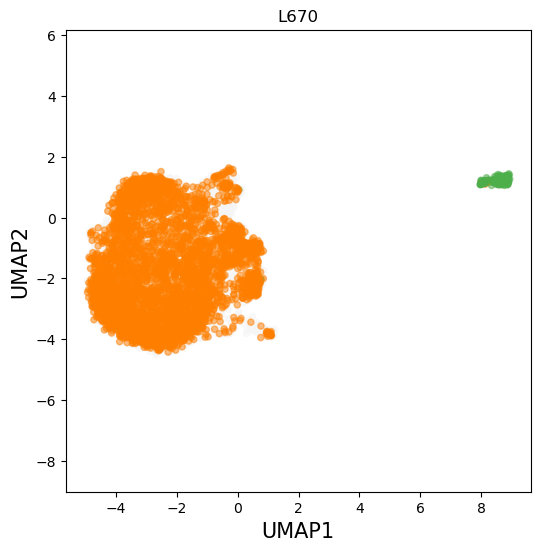

In [268]:
fig, ax = plt.subplots(figsize = (6,6))
g = 'L670'
cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
data_to_plot=labels[labels['group']==g].copy()
ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
ax.scatter(data_to_plot['UMAP1_1'], data_to_plot['UMAP2_1'], s = 20, alpha = 0.50, c = [cluster_color[x]  if x in ['C1','C2'] else 'black' for x in  data_to_plot['refined_cluster'].values] )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.title(g)
plt.savefig(f'/home/huangyong/temp/{g}_local_umap_670nt.pdf')

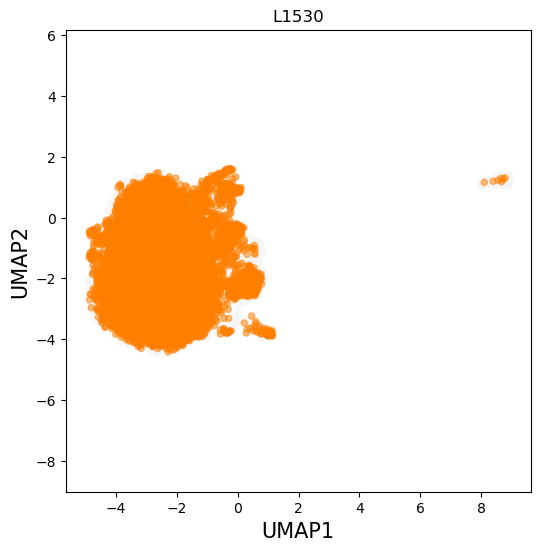

In [269]:
fig, ax = plt.subplots(figsize = (6,6))
g = 'L1530'
cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
data_to_plot=labels[labels['group']==g].copy()
ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
ax.scatter(data_to_plot['UMAP1_1'], data_to_plot['UMAP2_1'], s = 20, alpha = 0.50, c = [cluster_color[x]  if x in ['C1','C2'] else 'black' for x in  data_to_plot['refined_cluster'].values] )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.title(g)
plt.savefig(f'/home/huangyong/temp/{g}_local_umap_670nt.pdf')

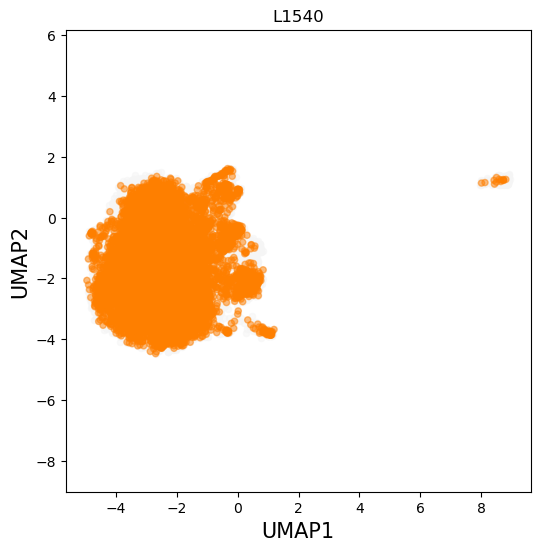

In [270]:
fig, ax = plt.subplots(figsize = (6,6))
g = 'L1540'
cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
data_to_plot=labels[labels['group']==g].copy()
ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
ax.scatter(data_to_plot['UMAP1_1'], data_to_plot['UMAP2_1'], s = 20, alpha = 0.50, c = [cluster_color[x]  if x in ['C1','C2'] else 'black' for x in  data_to_plot['refined_cluster'].values] )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.title(g)
plt.savefig(f'/home/huangyong/temp/{g}_local_umap_670nt.pdf')

In [271]:
data=pd.concat([ L1530_resdf.iloc[:,0:1530], L1540_resdf.iloc[:,0:1530]])
labels = pd.concat([ 
                    L1530_resdf[['group','UMAP1','UMAP2','GM_cluster']], 
                    L1540_resdf[['group','UMAP1','UMAP2','GM_cluster']]])

In [272]:
labels['refined_cluster'] = labels['GM_cluster'].copy()

In [273]:
# labels.loc[(labels['group']=='L270')&(labels['GM_cluster']==1),'refined_cluster'] = 'C1'
# labels.loc[(labels['group']=='L270')&(labels['GM_cluster']==0),'refined_cluster'] = 'C2'
# labels.loc[(labels['group']=='L320')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
# labels.loc[(labels['group']=='L320')&(labels['GM_cluster']==1),'refined_cluster'] = 'C2'
# labels.loc[(labels['group']=='L670')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
# labels.loc[(labels['group']=='L670')&(labels['GM_cluster']==1),'refined_cluster'] = 'C2'
labels.loc[(labels['group']=='L1530')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'
labels.loc[(labels['group']=='L1540')&(labels['GM_cluster']==0),'refined_cluster'] = 'C1'

In [274]:
np.random.seed(1)
UP = umap.UMAP(n_components=2)
concat_UMAP = pd.DataFrame(UP.fit_transform(data),columns = ['UMAP1', 'UMAP2'])
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',5:'black'}

In [275]:
labels['UMAP1_1'] = concat_UMAP['UMAP1'].values.copy()
labels['UMAP2_1'] = concat_UMAP['UMAP2'].values.copy()

In [276]:
plt.rcParams['pdf.fonttype'] = 42

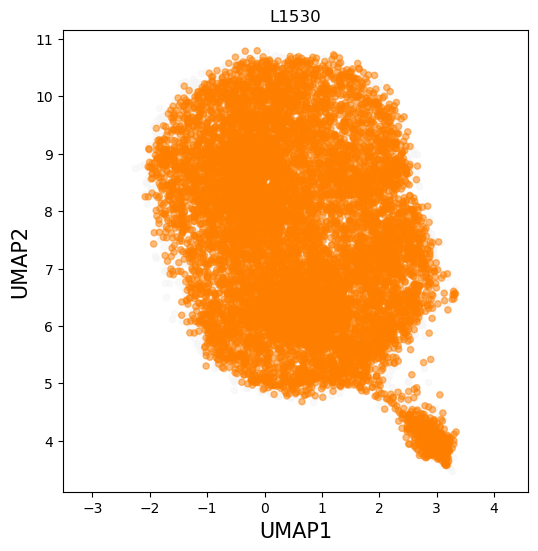

In [277]:
fig, ax = plt.subplots(figsize = (6,6))
g = 'L1530'
cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
data_to_plot=labels[labels['group']==g].copy()
ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
ax.scatter(data_to_plot['UMAP1_1'], data_to_plot['UMAP2_1'], s = 20, alpha = 0.50, c = [cluster_color[x]  if x in ['C1','C2'] else 'black' for x in  data_to_plot['refined_cluster'].values] )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.title(g)
plt.savefig(f'/home/huangyong/temp/{g}_local_umap_1530nt.pdf')

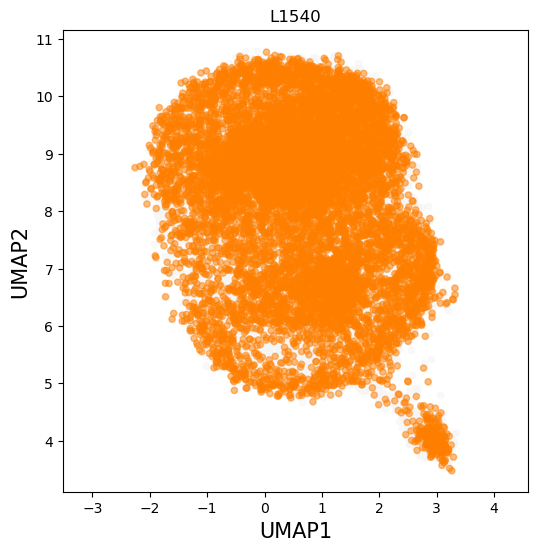

In [278]:
fig, ax = plt.subplots(figsize = (6,6))
g = 'L1540'
cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
data_to_plot=labels[labels['group']==g].copy()
ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
ax.scatter(data_to_plot['UMAP1_1'], data_to_plot['UMAP2_1'], s = 20, alpha = 0.50, c = [cluster_color[x]  if x in ['C1','C2'] else 'black' for x in  data_to_plot['refined_cluster'].values] )
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.title(g)
plt.savefig(f'/home/huangyong/temp/{g}_local_umap_1530nt.pdf')

In [260]:
import sklearn as skl

In [261]:
import os

In [262]:
os.environ['http_proxy'] = 'http://172.18.18.11:8888'
os.environ['https_proxy'] = 'http://172.18.18.11:8888'

In [263]:
os.environ['http_proxy'] = ''
os.environ['https_proxy'] = ''

In [264]:
from adjustText import adjust_text

In [309]:
df=pd.DataFrame([L270_score1[0:270],L270_score2[0:270],L320_score1[0:270],L320_score2[0:270],
               L670_score1[0:270],L670_score2[0:270],L1530_score1[0:270],L1540_score1[0:270]])

In [310]:
labels = ['L270_c1', 'L270_c2', 'L320_c1', 'L320_c2', 'L670_c1', 'L670_c2', 'L1530_c1', 'L1540_c1']

In [311]:
pct = [45.6, 54.4, 53.1, 46.9, 86.4, 13.6, 100, 100]

In [312]:
cluster = ['C1', 'C2', 'C1', 'C2', 'C1', 'C2', 'C1', 'C1',]

In [313]:
length = ['L270_280', 'L270_280', 'L320_330', 'L320_330', 'L670_680', 'L670_680', 'L1530_1540', 'L1540_1548' ]

In [314]:
pca = skl.decomposition.PCA(n_components=2)
concat_PCA=pd.DataFrame(pca.fit_transform(df), columns = ['PC1', 'PC2'])
concat_PCA['name'] = labels
concat_PCA['percent'] = pct
concat_PCA['conformation_cluster'] = cluster
concat_PCA['intermediate'] = length

In [315]:
print(pca.explained_variance_ratio_)

[0.60868639 0.13257532]


In [316]:
cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
alpha = {
    'L270_280' : 0.4,
    'L320_330' : 0.6,
    'L670_680' : 0.7,
    'L1530_1540': 0.8,
    'L1540_1548': 0.9
    
}

In [317]:
subseq=Cupineseq[0:270]
L270_energies = []
for i, scores in zip(labels, [L270_score1[0:270],L270_score2[0:270],L320_score1[0:270],L320_score2[0:270],
               L670_score1[0:270],L670_score2[0:270],L1530_score1[0:270],L1540_score1[0:270]]):
    _, e = predict_structure(subseq,shape_list=scores[0:270],si=-0.6,sm=2.2,md=150,
                        outdir=f'/home/huangyong/temp/{i}_270',method='RNAfold',clean=False)
    L270_energies.append(e)

/home/huangyong/temp/L270_c1_270
/home/huangyong/temp/L270_c2_270
/home/huangyong/temp/L320_c1_270
/home/huangyong/temp/L320_c2_270
/home/huangyong/temp/L670_c1_270
/home/huangyong/temp/L670_c2_270
/home/huangyong/temp/L1530_c1_270
/home/huangyong/temp/L1540_c1_270


In [318]:
concat_PCA['energy'] = L270_energies

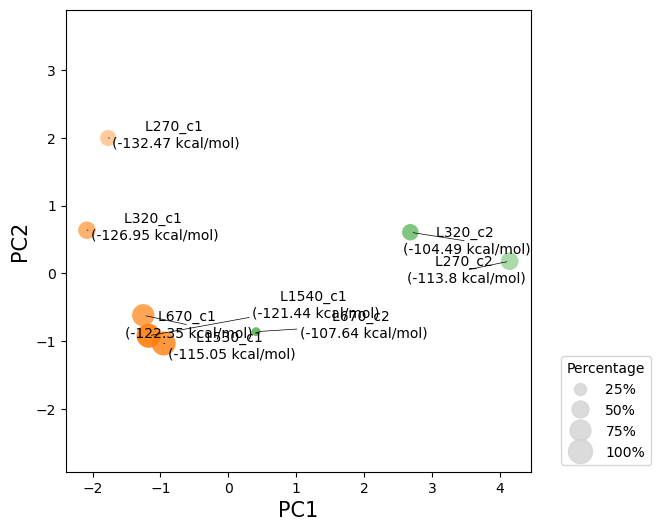

In [319]:
fig, ax = plt.subplots(figsize = (6,6))
# g = 'L1530'
# cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
# data_to_plot=labels[labels['group']==g].copy()
# ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
scatter = ax.scatter(concat_PCA['PC1'], concat_PCA['PC2'], s = 3*concat_PCA['percent'], 
           alpha = [alpha[x]  for x in  concat_PCA['intermediate'].values],
           edgecolors='none',
           c = concat_PCA['conformation_cluster'],cmap=cluster_color,
           )
texts=[]
for i in concat_PCA.index:
    texts.append(ax.text(concat_PCA.loc[i, 'PC1'], concat_PCA.loc[i, 'PC2'], ha='left', va='top',
                         s="%s \n(%s kcal/mol)" % (concat_PCA.loc[i, 'name'], concat_PCA.loc[i, 'energy'])))

adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5),ax=ax)

ax.set_xlabel('PC1', fontsize = 15)
ax.set_ylabel('PC2', fontsize = 15)
ax.set_aspect('equal', 'box')

# kw1 = dict(prop="colors")
# legend1 = ax.legend(*scatter.legend_elements(**kw1),
#                     loc="lower right", title="conformation", bbox_to_anchor = (1.05, 1.05))
# ax.add_artist(legend1)

kw2 = dict(prop="sizes", num=4, color='lightgrey', fmt="{x:.0f}%", alpha=0.8, func = lambda s: s/3)
legend2 = ax.legend(*scatter.legend_elements(**kw2),
                    loc="lower left", title="Percentage",  bbox_to_anchor = (1.05, 0.0))

plt.axis('equal')
plt.savefig('/home/huangyong/temp/PCA_reactivity_scores_270nt.pdf', bbox_inches='tight')

In [275]:
df2=pd.DataFrame([L320_score1[0:320],L320_score2[0:320],
               L670_score1[0:320],L670_score2[0:320],L1530_score1[0:320],L1540_score1[0:320]])

In [276]:
pca = skl.decomposition.PCA(n_components=2)
concat_PCA=pd.DataFrame(pca.fit_transform(df2), columns = ['PC1', 'PC2'])
concat_PCA['name'] = labels[2:]
concat_PCA['percent'] = pct[2:]
concat_PCA['conformation_cluster'] = cluster[2:]
concat_PCA['intermediate'] = length[2:]

In [277]:
subseq=Cupineseq[0:320]
L320_energies = []
for i, scores in zip(labels[2:], [L320_score1[0:320],L320_score2[0:320],
               L670_score1[0:320],L670_score2[0:320],L1530_score1[0:320],L1540_score1[0:320]]):
    _, e = predict_structure(subseq,shape_list=scores[0:320],si=-0.6,sm=2.2,md=150,
                        outdir=f'/home/huangyong/temp/{i}_320',method='RNAfold',clean=False)
    L320_energies.append(e)

/home/huangyong/temp/L320_c1_320
/home/huangyong/temp/L320_c2_320
/home/huangyong/temp/L670_c1_320
/home/huangyong/temp/L670_c2_320
/home/huangyong/temp/L1530_c1_320
/home/huangyong/temp/L1540_c1_320


In [278]:
concat_PCA['energy'] = L320_energies

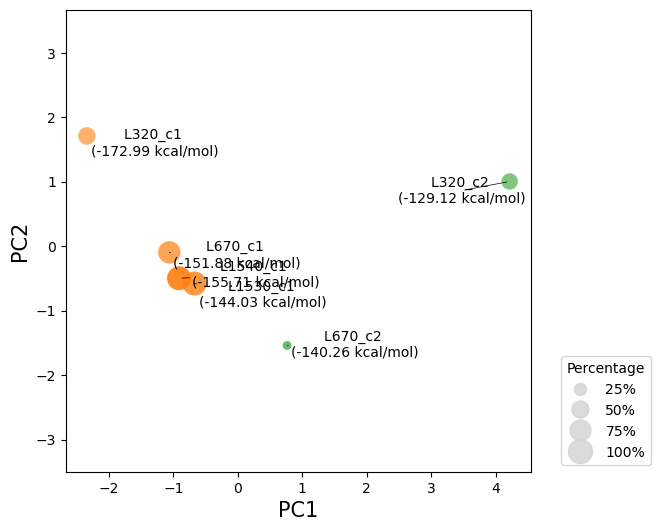

In [279]:
fig, ax = plt.subplots(figsize = (6,6))
# g = 'L1530'
# cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
# data_to_plot=labels[labels['group']==g].copy()
# ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
scatter = ax.scatter(concat_PCA['PC1'], concat_PCA['PC2'], s = 3*concat_PCA['percent'], 
           alpha = [alpha[x]  for x in  concat_PCA['intermediate'].values],
                     edgecolors='none',
           c = concat_PCA['conformation_cluster'],cmap=cluster_color,
           )
texts=[]
for i in concat_PCA.index:
    texts.append(ax.text(concat_PCA.loc[i, 'PC1'], concat_PCA.loc[i, 'PC2'], ha='left', va='top',
                         s="%s \n(%s kcal/mol)" % (concat_PCA.loc[i, 'name'], concat_PCA.loc[i, 'energy'])))
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5),ax=ax)
ax.set_xlabel('PC1', fontsize = 15)
ax.set_ylabel('PC2', fontsize = 15)
ax.set_aspect('equal', 'box')

# kw1 = dict(prop="colors")
# legend1 = ax.legend(*scatter.legend_elements(**kw1),
#                     loc="lower right", title="conformation", bbox_to_anchor = (1.05, 1.05))
# ax.add_artist(legend1)

kw2 = dict(prop="sizes", num=4, color='lightgrey', fmt="{x:.0f}%", alpha=0.8, func = lambda s: s/3)
legend2 = ax.legend(*scatter.legend_elements(**kw2),
                    loc="lower left", title="Percentage",  bbox_to_anchor = (1.05, 0.0))

plt.axis('equal')
plt.savefig('/home/huangyong/temp/PCA_reactivity_scores_320nt.pdf', bbox_inches='tight')

In [280]:
df3=pd.DataFrame([L670_score1[0:670],L670_score2[0:670],L1530_score1[0:670],L1540_score1[0:670]])

In [281]:
pca = skl.decomposition.PCA(n_components=2)
concat_PCA=pd.DataFrame(pca.fit_transform(df3), columns = ['PC1', 'PC2'])
concat_PCA['name'] = labels[4:]
concat_PCA['percent'] = pct[4:]
concat_PCA['conformation_cluster'] = cluster[4:]
concat_PCA['intermediate'] = length[4:]

In [282]:
subseq=Cupineseq[0:670]
L670_energies = []
for i, scores in zip(labels[2:], [L670_score1[0:670],L670_score2[0:670],L1530_score1[0:670],L1540_score1[0:670]]):
    _, e = predict_structure(subseq,shape_list=scores[0:670],si=-0.6,sm=2.2,md=150,
                        outdir=f'/home/huangyong/temp/{i}_670',method='RNAfold',clean=False)
    L670_energies.append(e)

/home/huangyong/temp/L320_c1_670
/home/huangyong/temp/L320_c2_670
/home/huangyong/temp/L670_c1_670
/home/huangyong/temp/L670_c2_670


In [283]:
concat_PCA['energy'] = L670_energies

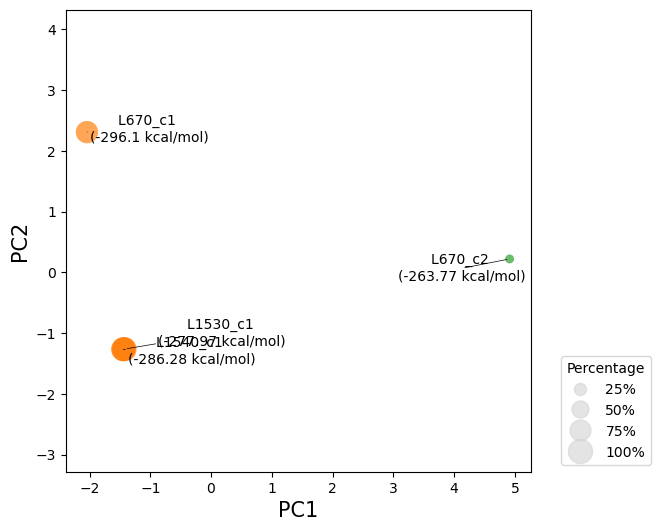

In [284]:
fig, ax = plt.subplots(figsize = (6,6))
# g = 'L1530'
# cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
# data_to_plot=labels[labels['group']==g].copy()
# ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
scatter = ax.scatter(concat_PCA['PC1'], concat_PCA['PC2'], s = 3*concat_PCA['percent'], 
           alpha = [alpha[x]  for x in  concat_PCA['intermediate'].values],
                     edgecolors='none',
           c = concat_PCA['conformation_cluster'],cmap=cluster_color,
           )
# ax.plot(concat_PCA['PC1'], concat_PCA['PC2'], '--',lw=1, c='grey')
texts=[]
for i in concat_PCA.index:
    texts.append(ax.text(concat_PCA.loc[i, 'PC1'], concat_PCA.loc[i, 'PC2'], ha='left', va='top',
                         s="%s \n(%s kcal/mol)" % (concat_PCA.loc[i, 'name'], concat_PCA.loc[i, 'energy'])))
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5),ax=ax)
ax.set_xlabel('PC1', fontsize = 15)
ax.set_ylabel('PC2', fontsize = 15)
ax.set_aspect('equal', 'box')

# kw1 = dict(prop="colors")
# legend1 = ax.legend(*scatter.legend_elements(**kw1),
#                     loc="lower right", title="conformation", bbox_to_anchor = (1.05, 1.05))
# ax.add_artist(legend1)

kw2 = dict(prop="sizes", num=4, color='lightgrey', fmt="{x:.0f}%", alpha=0.6, func = lambda s: s/3)
legend2 = ax.legend(*scatter.legend_elements(**kw2),
                    loc="lower left", title="Percentage",  bbox_to_anchor = (1.05, 0.0))

plt.axis('equal')
plt.savefig('/home/huangyong/temp/PCA_reactivity_scores_670nt.pdf', bbox_inches='tight')

In [60]:
np.random.seed(1)
UP = umap.UMAP(n_components=2)
concat_UMAP = pd.DataFrame(UP.fit_transform(df),columns = ['UMAP1', 'UMAP2'])

/home/huangyong/anaconda3/envs/gcc/lib/python3.8/site-packages/umap/umap_.py:2433: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


In [64]:
concat_UMAP['conformation'] = labels

In [65]:
concat_UMAP

,UMAP1,UMAP2,conformation
0,-7.878224,17.284300,L270_c1
1,-5.675589,17.514090,L270_c2
2,-7.309770,16.762827,L320_c1
3,-5.792824,18.332767,L320_c2
4,-6.795268,17.392092,L670_c1
5,-6.620939,18.726931,L670_c2
6,-7.949365,18.264269,L1530_c1
7,-7.164063,18.091270,L1540_c1


(-8.063053965568542, -5.561899781227112, 16.66462173461914, 18.825135803222658)

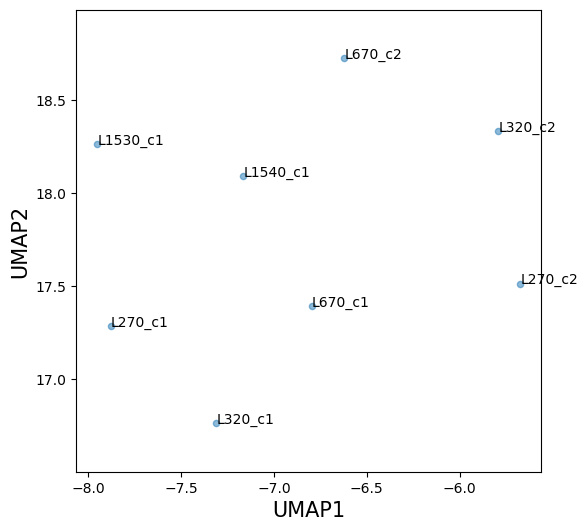

In [69]:
fig, ax = plt.subplots(figsize = (6,6))
# g = 'L1530'
# cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
# data_to_plot=labels[labels['group']==g].copy()
# ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
ax.scatter(concat_UMAP['UMAP1'], concat_UMAP['UMAP2'], s = 20, alpha = 0.50 )
for i in concat_UMAP.index:
    ax.text(concat_UMAP.loc[i, 'UMAP1'], concat_UMAP.loc[i, 'UMAP2'], s=concat_UMAP.loc[i,'conformation'])
ax.set_xlabel('UMAP1', fontsize = 15)
ax.set_ylabel('UMAP2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')

<Figure size 400x400 with 0 Axes>

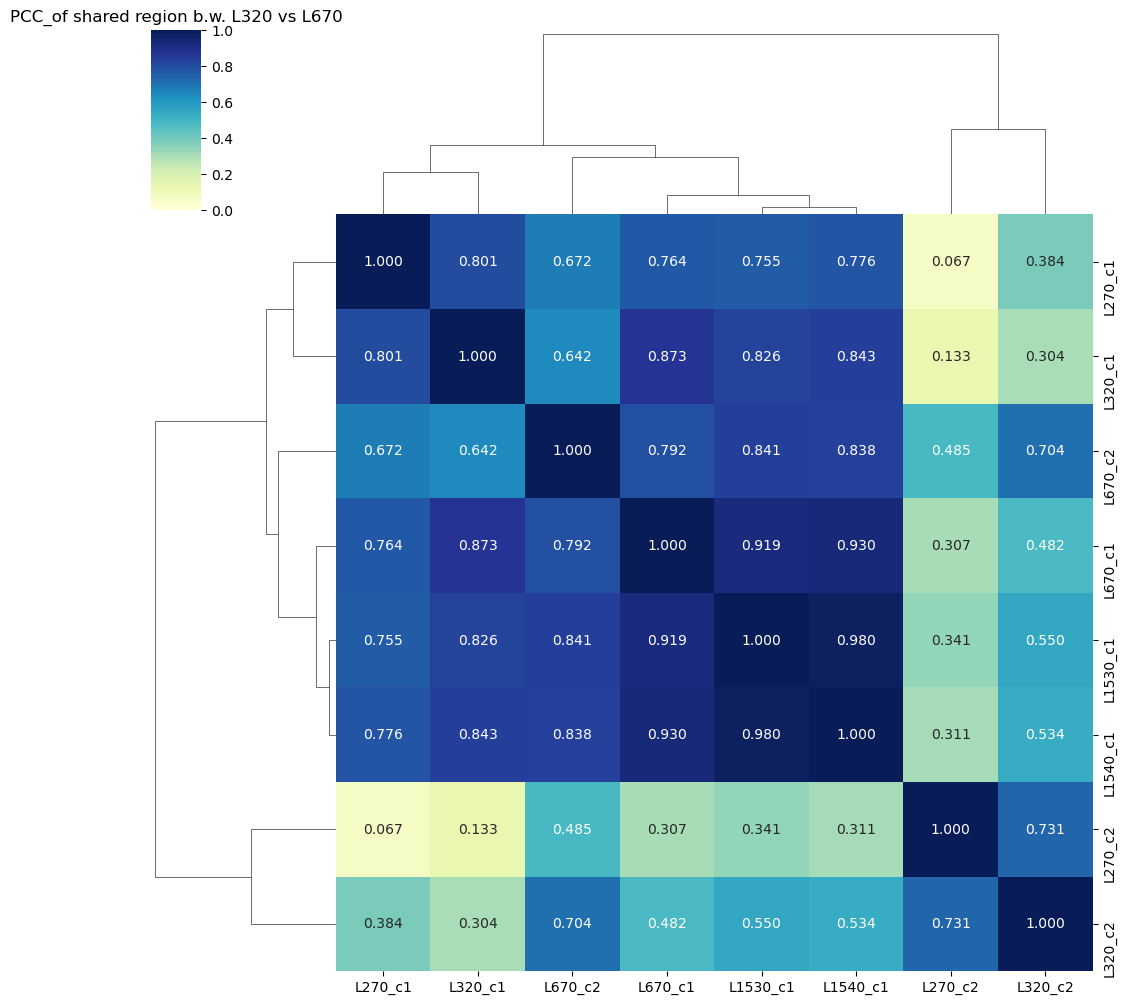

In [202]:
scorelist=[L270_score1[0:270],L270_score2[0:270],L320_score1[0:270],L320_score2[0:270],
               L670_score1[0:270],L670_score2[0:270],L1530_score1[0:270],L1540_score1[0:270]]
namelists=['L270_c1', 'L270_c2', 'L320_c1', 'L320_c2', 'L670_c1', 'L670_c2', 'L1530_c1', 'L1540_c1']
n=8
pearsonr_df = General.init_pd_rect(n, n, namelists, namelists)
for i in range(n):
    for j in range(i, n):
        t, p = scipy.stats.pearsonr(scorelist[i], scorelist[j])
        pearsonr_df.iloc[i, j] = pearsonr_df.iloc[j, i] = round(t, 3)

plt.figure(figsize=(4,4))
sns.clustermap(pearsonr_df, cmap='YlGnBu', annot=True, fmt=".3f",vmin=0, vmax=1)
plt.title("PCC_of shared region b.w. L320 vs L670")
plt.xticks(rotation=45)
plt.show()

In [286]:
def SHAPEWindowcorrelation(shape1,shape2,windowsize):
    my_list1 = [0 if math.isnan(x) else x for x in shape1]
    my_list2 = [0 if math.isnan(x) else x for x in shape2]
    corre=[]
    start=0
    size=windowsize
    while start+size < len(my_list1):
        end=start+size
        subshape1=my_list1[start:end]
        subshape2=my_list2[start:end]
        t, p = scipy.stats.pearsonr(subshape1, subshape2)
        corre.append(round(t, 3))
        start+=1
    # head=[0 for i in range(int(windowsize/2))]
    return corre

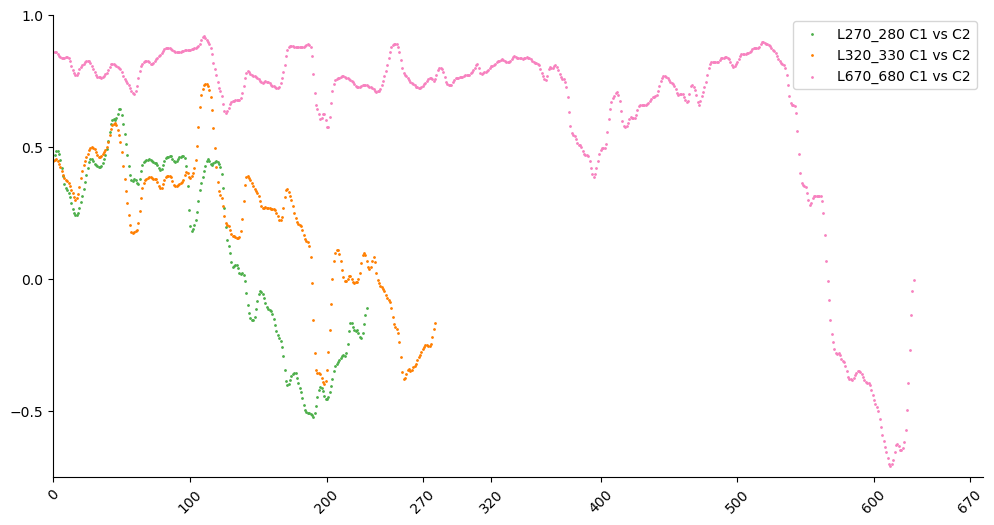

0.12198260869565217 0.20036785714285715 0.6243587301587301


In [294]:
L270_correlation=SHAPEWindowcorrelation(L270_score1,L270_score2,50)
L270correlation_smooth=gaussian_filter1d(L270_correlation, sigma=1)
L320_correlation=SHAPEWindowcorrelation(L320_score1,L320_score2,50)
L320correlation_smooth=gaussian_filter1d(L320_correlation, sigma=1)
L670_correlation=SHAPEWindowcorrelation(L670_score1,L670_score2,50)
L670correlation_smooth=gaussian_filter1d(L670_correlation, sigma=1)


fig, ax = plt.subplots(figsize = (12,6))
# ax = fig.add_subplot(4,1,1) 
ax.scatter([i for i in range(len(L270correlation_smooth))], L270correlation_smooth.tolist(), s = 1,color ='#4daf4a' ,label='L270_280 C1 vs C2')
ax.scatter([i for i in range(len(L320correlation_smooth))], L320correlation_smooth.tolist(), s = 1,color ='#ff7f00' ,label='L320_330 C1 vs C2')
ax.scatter([i for i in range(len(L670correlation_smooth))], L670correlation_smooth.tolist(), s = 1,color ='#f781bf' ,label='L670_680 C1 vs C2')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.legend(loc="upper right")


plt.ylim(-0.75,1)
plt.yticks([-0.50,0.0,0.5,1])

plt.xlim(0,680)
# plt.ylim(0,1)
plt.xticks([0,100,200,270,320,400,500,600,670])
plt.xticks(rotation=45)
plt.show()
# fig.savefig("./PCC_local_slidingwindow_C1_vs_C2.pdf")
#plt.close()
print(np.mean(L270_correlation), np.mean(L320_correlation), np.mean(L670_correlation))

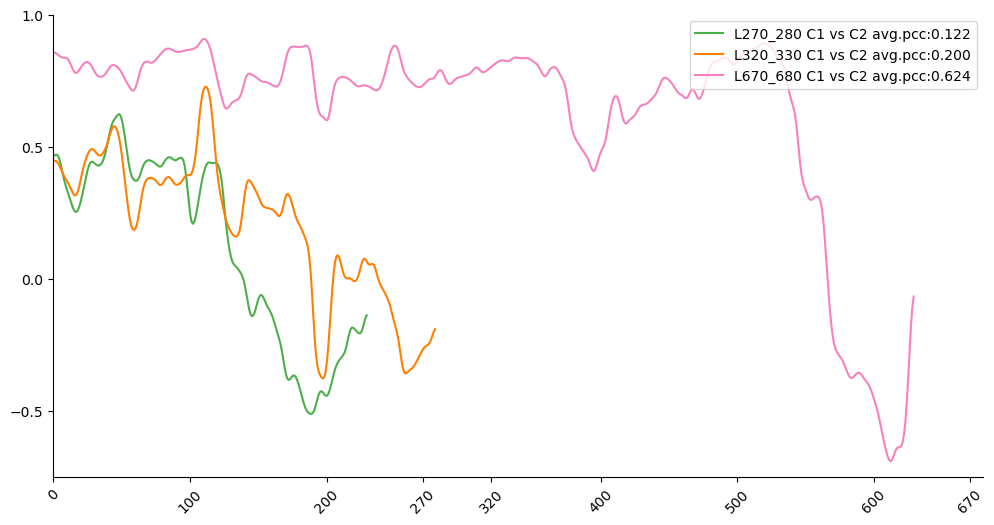

0.12198260869565217 0.20036785714285715 0.6243587301587301


In [300]:
L270_correlation=SHAPEWindowcorrelation(L270_score1,L270_score2,50)
L270correlation_smooth=gaussian_filter1d(L270_correlation, sigma=2)
L320_correlation=SHAPEWindowcorrelation(L320_score1,L320_score2,50)
L320correlation_smooth=gaussian_filter1d(L320_correlation, sigma=2)
L670_correlation=SHAPEWindowcorrelation(L670_score1,L670_score2,50)
L670correlation_smooth=gaussian_filter1d(L670_correlation, sigma=2)


fig, ax = plt.subplots(figsize = (12,6))
# ax = fig.add_subplot(4,1,1) 
ax.plot([i for i in range(len(L270correlation_smooth))], L270correlation_smooth.tolist(),'-',color ='#4daf4a' ,
        label=f'L270_280 C1 vs C2 avg.pcc:{np.mean(L270_correlation):0.3f}')
ax.plot([i for i in range(len(L320correlation_smooth))], L320correlation_smooth.tolist(),'-',color ='#ff7f00' ,
        label=f'L320_330 C1 vs C2 avg.pcc:{np.mean(L320_correlation):0.3f}')
ax.plot([i for i in range(len(L670correlation_smooth))], L670correlation_smooth.tolist(),'-',color ='#f781bf' ,
        label=f'L670_680 C1 vs C2 avg.pcc:{np.mean(L670_correlation):0.3f}')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.legend(loc="upper right")


plt.ylim(-0.75,1)
plt.yticks([-0.50,0.0,0.5,1])

plt.xlim(0,680)
# plt.ylim(0,1)
plt.xticks([0,100,200,270,320,400,500,600,670])
plt.xticks(rotation=45)
plt.show()
fig.savefig("/home/huangyong/temp/PCC_local_slidingwindow_C1_vs_C2.pdf")
#plt.close()
print(np.mean(L270_correlation), np.mean(L320_correlation), np.mean(L670_correlation))

In [303]:
df4=pd.DataFrame([L270_score1[0:200],L270_score2[0:200],L320_score1[0:200],L320_score2[0:200],
               L670_score1[0:200],L670_score2[0:200],L1530_score1[0:200],L1540_score1[0:200]])

In [304]:
pca = skl.decomposition.PCA(n_components=2)
concat_PCA=pd.DataFrame(pca.fit_transform(df4), columns = ['PC1', 'PC2'])
concat_PCA['name'] = labels
concat_PCA['percent'] = pct
concat_PCA['conformation_cluster'] = cluster
concat_PCA['intermediate'] = length

In [305]:
subseq=Cupineseq[0:200]
L200_energies = []
for i, scores in zip(labels, [L270_score1[0:200],L270_score2[0:200],L320_score1[0:200],L320_score2[0:200],
               L670_score1[0:200],L670_score2[0:200],L1530_score1[0:200],L1540_score1[0:200]]):
    _, e = predict_structure(subseq,shape_list=scores[0:200],si=-0.6,sm=2.2,md=150,
                        outdir=f'/home/huangyong/temp/{i}_200',method='RNAfold',clean=False)
    L200_energies.append(e)

/home/huangyong/temp/L270_c1_200
/home/huangyong/temp/L270_c2_200
/home/huangyong/temp/L320_c1_200
/home/huangyong/temp/L320_c2_200
/home/huangyong/temp/L670_c1_200
/home/huangyong/temp/L670_c2_200
/home/huangyong/temp/L1530_c1_200
/home/huangyong/temp/L1540_c1_200


In [306]:
concat_PCA['energy'] = L200_energies

(-2.017062739379908,
 3.5518263179821536,
 -1.2788993671887006,
 1.3597526772977833)

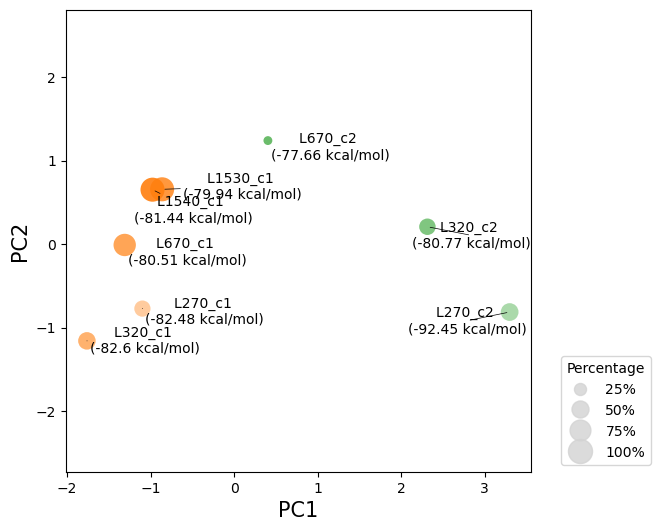

In [307]:
fig, ax = plt.subplots(figsize = (6,6))
# g = 'L1530'
# cluster_color = { 'C2': '#4daf4a', 'C1': '#ff7f00'}
# data_to_plot=labels[labels['group']==g].copy()
# ax.scatter(labels['UMAP1_1'], labels['UMAP2_1'], s = 20, alpha = 0.50, c = 'whitesmoke' )
scatter = ax.scatter(concat_PCA['PC1'], concat_PCA['PC2'], s = 3*concat_PCA['percent'], 
           alpha = [alpha[x]  for x in  concat_PCA['intermediate'].values],
           edgecolors='none',
           c = concat_PCA['conformation_cluster'],cmap=cluster_color,
           )
texts=[]
for i in concat_PCA.index:
    texts.append(ax.text(concat_PCA.loc[i, 'PC1'], concat_PCA.loc[i, 'PC2'], ha='left', va='top',
                         s="%s \n(%s kcal/mol)" % (concat_PCA.loc[i, 'name'], concat_PCA.loc[i, 'energy'])))

adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5),ax=ax)

ax.set_xlabel('PC1', fontsize = 15)
ax.set_ylabel('PC2', fontsize = 15)
ax.set_aspect('equal', 'box')

# kw1 = dict(prop="colors")
# legend1 = ax.legend(*scatter.legend_elements(**kw1),
#                     loc="lower right", title="conformation", bbox_to_anchor = (1.05, 1.05))
# ax.add_artist(legend1)

kw2 = dict(prop="sizes", num=4, color='lightgrey', fmt="{x:.0f}%", alpha=0.8, func = lambda s: s/3)
legend2 = ax.legend(*scatter.legend_elements(**kw2),
                    loc="lower left", title="Percentage",  bbox_to_anchor = (1.05, 0.0))

plt.axis('equal')
# plt.savefig('/home/huangyong/temp/PCA_reactivity_scores_270nt.pdf', bbox_inches='tight')


In [308]:
print(pca.explained_variance_ratio_)

[0.66807452 0.1394285 ]
